# MOFA+ on simulated PerturbSeq contexts (gene-module orientation)

Adapted from `ChemoGeneticScreens/SRC/Notebooks/19_MOFA_PosteriorMatrices.ipynb`.

**Setup (transposed from the source notebook).** We fit MOFA+ on the
empirical log2FC tensor with:

- **samples = genes** (5000)
- **features = perturbations** (60)
- **views   = contexts** (A, B, C)

So each factor is a **gene module** — a set of genes that co-vary across
perturbations the same way. The per-view loading matrix `W_v` says how each
perturbation modulates that module in context `v`.

This is the appropriate orientation for the EXTRACT use case
(gene-program discovery). The transposed (perts-as-samples) orientation
would instead give "perturbation programs", which is what the
ChemoGeneticScreens notebook does.

Empirical log2FC matrices are computed exactly as in
`09_GenerateContextDependentResponses.ipynb`:
`log2(X+1)` per cell, mean per perturbation minus mean over control cells
(`perturbation == 'control'`), using `adata.layers['raw_counts']` if present,
else `adata.X`.

## Outputs (in `MOFA/`)
```
mofa_model.hdf5             full MOFA model (loadable via mofapy2)
factors.parquet             (n_genes, n_factors) gene-loading matrix Z
loadings_<context>.parquet  (n_perts, n_factors) per-view perturbation loadings W_v
factor_view_alpha.parquet   (n_factors, n_views) 1/R² — small = factor active in view
variance_explained.parquet  per-(view, factor) R²
axes.json                   contexts / perturbations / genes ordering
```


## 1. Imports


In [46]:
import json, time, warnings
from pathlib import Path
from typing import Dict, List, Tuple

import h5py
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


## 2. Configuration


In [47]:
PROJECT_DIR = Path('/home/beraslan/Projects/ModuleFinder')
DATA_DIR    = PROJECT_DIR / 'SRC' / 'DATA'
OUT_DIR     = PROJECT_DIR / 'MOFA'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONTEXTS    = ['A', 'B', 'C']
H5AD_PATHS  = {c: DATA_DIR / f'perturbseq_{c}.h5ad' for c in CONTEXTS}

# Model knobs
N_FACTORS         = 15      # initial number of factors; ARD prunes unused ones
GENE_MEDIAN_THR   = 0.0     # drop genes whose max-across-contexts |median delta| is below this
MAX_ITER          = 1000
SEED              = 0
SCALE_VIEWS       = False   # if True, MOFA scales variance-per-view to 1 before fitting

print(f'inputs:  {DATA_DIR}')
print(f'outputs: {OUT_DIR}')


inputs:  /home/beraslan/Projects/ModuleFinder/SRC/DATA
outputs: /home/beraslan/Projects/ModuleFinder/MOFA


## 3. Load `perturbseq_<context>.h5ad` and compute empirical log2FC per context

Uses the same formula as `09_GenerateContextDependentResponses.ipynb`:
`log2(X + 1)` per cell, mean per perturbation minus mean over control cells
(`perturbation == 'control'`). Falls back from `layers['raw_counts']` to `X`.


In [48]:
# Empirical log2FC per context: mean(log2(X+1)) per pert minus control mean
# (mirrors `empirical_log2fc` in 09_GenerateContextDependentResponses.ipynb)
def empirical_log2fc(adata):
    raw = adata.layers['raw_counts'] if 'raw_counts' in adata.layers else adata.X
    if sp.issparse(raw):
        raw = raw.toarray()
    raw = np.asarray(raw, dtype=np.float64)
    groups = adata.obs['perturbation'].values
    ctrl = groups == 'control'
    if ctrl.sum() == 0:
        raise RuntimeError("no cells with perturbation == 'control'")
    log2_ctrl = np.log2(raw[ctrl] + 1).mean(axis=0)
    perts = [p for p in np.unique(groups) if p != 'control']
    rows = {p: np.log2(raw[groups == p] + 1).mean(axis=0) - log2_ctrl for p in perts}
    return pd.DataFrame(rows, index=adata.var_names).T   # (n_perts × n_genes)

def load_per_context(h5ad_paths: Dict[str, Path]):
    """Return (mats, contexts) where mats[ctx] is a (n_perts × n_genes) log2FC DataFrame."""
    mats, contexts = {}, []
    for ctx, fp in h5ad_paths.items():
        a = sc.read_h5ad(fp)
        df = empirical_log2fc(a)
        df.index.name = 'perturbation'
        layer_used = 'raw_counts' if 'raw_counts' in a.layers else 'X'
        mats[ctx] = df
        contexts.append(ctx)
        print(f'  context {ctx}: {df.shape[0]:>4d} perts × {df.shape[1]:>6d} genes  '
              f'(n_cells={a.n_obs}, layer={layer_used})')
    return mats, contexts

mats, contexts = load_per_context(H5AD_PATHS)
print(f'\n{len(contexts)} contexts loaded')


  context A:   60 perts ×   5000 genes  (n_cells=13000, layer=X)
  context B:   60 perts ×   5000 genes  (n_cells=13000, layer=X)
  context C:   60 perts ×   5000 genes  (n_cells=13000, layer=X)

3 contexts loaded


## 4. Align: intersect perturbations and genes across contexts

Restrict to perturbations & genes present in every context.
Optionally drop genes whose max-across-contexts |median log2FC| is below
`GENE_MEDIAN_THR` (we leave it at 0.0 — keep all genes).


In [49]:
def align(mats, contexts, gene_median_thr):
    common_perts = sorted(set.intersection(*(set(df.index)   for df in mats.values())))
    common_genes = sorted(set.intersection(*(set(df.columns) for df in mats.values())))
    print(f'Intersection: {len(common_perts)} perts × {len(common_genes)} genes')

    if gene_median_thr > 0:
        per_drug_max_abs_med = np.zeros(len(common_genes))
        for d in contexts:
            v = mats[d].loc[common_perts, common_genes].abs().median(axis=0).values
            per_drug_max_abs_med = np.maximum(per_drug_max_abs_med, v)
        keep = per_drug_max_abs_med >= gene_median_thr
        common_genes = [g for g, k in zip(common_genes, keep) if k]
        print(f'After |median log2FC| ≥ {gene_median_thr}: {len(common_genes)} genes kept')

    aligned = {d: mats[d].loc[common_perts, common_genes] for d in contexts}
    return aligned, common_perts, common_genes

aligned, perts, genes = align(mats, contexts, GENE_MEDIAN_THR)
print(f'\nFinal aligned tensor: {len(perts)} perts × {len(genes)} genes × {len(contexts)} views')


Intersection: 60 perts × 5000 genes

Final aligned tensor: 60 perts × 5000 genes × 3 views


### Quick sanity-check on the data scale

Δ-values are continuous; with heavy-tailed simulator output we expect a wide
spread. Look at the histogram on a log y-axis.


A aligned matrix shape: (60, 5000)  (rows=perts, cols=genes; will be transposed before MOFA)
  mean=0.0215, std=0.6137
  |log2FC| quantiles 50/90/99/max:  [0.0402 0.1149 4.442 ]  max=5.337


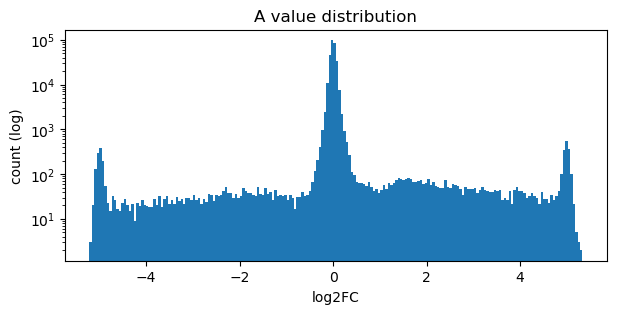

In [50]:
sample_ctx = contexts[0]
v = aligned[sample_ctx].values   # still (n_perts × n_genes) at this stage
print(f'{sample_ctx} aligned matrix shape: {v.shape}  '
      f'(rows=perts, cols=genes; will be transposed before MOFA)')
print(f'  mean={v.mean():.4f}, std={v.std():.4f}')
print(f'  |log2FC| quantiles 50/90/99/max:  '
      f'{np.quantile(np.abs(v), [.5,.9,.99]).round(4)}  max={np.abs(v).max():.3f}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(v.flatten(), bins=200, log=True)
ax.set_xlabel('log2FC'); ax.set_ylabel('count (log)')
ax.set_title(f'{sample_ctx} value distribution')
plt.show()


## 5. Build the MOFA+ data structure

`mofapy2` expects `data[v][g]` = numpy `(n_samples × n_features)` matrix per
(view, group). We have one sample group, so g=0; one view per context.


In [51]:
def to_mofa_inputs(aligned, contexts):
    """Transpose each (n_perts × n_genes) matrix to (n_genes × n_perts).

    After transpose:
      - samples = genes      → sample_names
      - features = perts     → feature_names
      - views = contexts
    """
    data = [[aligned[c].T.values.astype(np.float32)] for c in contexts]
    sample_names  = list(aligned[contexts[0]].columns)   # gene symbols
    feature_names = list(aligned[contexts[0]].index)     # perturbation names
    return data, sample_names, feature_names

data, sample_names, feature_names = to_mofa_inputs(aligned, contexts)
print(f'data is a list of {len(data)} views, each list of 1 group')
print(f'view 0 ({contexts[0]}): {data[0][0].shape}  '
      f'(samples={len(sample_names)} genes, features={len(feature_names)} perts)')


data is a list of 3 views, each list of 1 group
view 0 (A): (5000, 60)  (samples=5000 genes, features=60 perts)


## 6. Configure MOFA+

Key choices:

- `likelihoods='gaussian'` — explicitly set; MOFA's auto-inference can pick
  `bernoulli` when most values are near zero (which our shrunken logFCs are).
- `spikeslab_weights=True` — sparsity prior on gene loadings.
- `ard_factors=True` — per-(view, factor) variance prior. **This is what gives
  shared/private decomposition for free.** Small α = factor active in view;
  large α = loading shrunk toward zero.
- `ard_weights=True` — column-level sparsity on top of spike-and-slab.
- `convergence_mode='medium'` — tightness of the ELBO stopping criterion.


In [52]:
from mofapy2.run.entry_point import entry_point

# MOFA+ requires globally unique feature names across views.
# Use bare gene symbols for downstream output (loadings parquet index),
# but pass context-prefixed names ("A__GENE", ...) into MOFA itself.
features_per_view = [[f'{ctx}__{g}' for g in feature_names] for ctx in contexts]

ent = entry_point()
ent.set_data_options(scale_views=SCALE_VIEWS, scale_groups=False)
ent.set_data_matrix(
    data,
    views_names=contexts,
    groups_names=['all'],
    samples_names=[sample_names],
    features_names=features_per_view,
    likelihoods=['gaussian'] * len(contexts),
)
ent.set_model_options(
    factors=N_FACTORS,
    spikeslab_weights=True,
    ard_factors=True,
    ard_weights=True,
)
ent.set_train_options(
    iter=MAX_ITER,
    convergence_mode='medium',
    startELBO=1,
    freqELBO=10,
    gpu_mode=False,
    seed=SEED,
    verbose=True,
)
print('MOFA+ entry point configured')



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Successfully loaded view='A' group='all' with N=5000 samples and D=60 features...
Successfully loaded view='B' group='all' with N=5000 samples and D=60 features...
Successfully loaded view='C' group='all' with N=5000 samples and D=60 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True

## 7. Build & run

This is the long step. Expect 5–20 minutes depending on data size and
convergence. Watch for ELBO updates printed by MOFA — should monotonically
increase and stabilize.


In [53]:
t0 = time.time()
ent.build()
ent.run()
print(f'\ntrained in {(time.time()-t0)/60:.1f} min')




######################################
## Training the model with seed 0 ##
######################################


ELBO before training:
Z=-22526.65  W=-3479.24  Tau=-960.92  Y=-8158204.21  AlphaZ=-459.88  AlphaW=-1379.65  ThetaW=0.00  
Total: -8187010.56

Iteration 1: time=0.12, ELBO=-525406.92, deltaELBO=7661603.641 (93.58243265%), Factors=15
- ELBO decomposition:  Z=-11847.63  W=-3437.09  Tau=-1695.18  Y=-506443.03  AlphaZ=-520.94  AlphaW=-1463.05  ThetaW=0.00  
- Time spent in ELBO computation: 2.3%
- Variance explained:  View 0: 24.16%   View 1: 24.25%   View 2: 21.48%
- Fraction of zero weights:  View 0: 87%   View 1: 88%   View 2: 89%
- Maximum correlation between factors: 0.79
- Factor norms:  2.18 1.87 1.26 0.89 0.34 0.07 0.13 0.03 0.04 0.00 0.00 0.00 0.00 0.00 0.00
- Tau per view (average):  View 0: 11.24   View 1: 12.13   View 2: 13.53


Iteration 2: time=0.10, Factors=15
- Variance explained:  View 0: 86.19%   View 1: 87.19%   View 2: 86.29%
- Fraction of zero weights: 

## 8. Save the canonical HDF5 model

`save_data=False` keeps the file small — we already have the input data in CSVs.


In [36]:
model_path = OUT_DIR / 'mofa_model.hdf5'
ent.save(str(model_path), save_data=False)
print(f'Saved model → {model_path}  ({model_path.stat().st_size/1e6:.1f} MB)')


Saving model in /home/beraslan/Projects/ModuleFinder/MOFA/mofa_model.hdf5...
Saved model → /home/beraslan/Projects/ModuleFinder/MOFA/mofa_model.hdf5  (2.5 MB)


## 9. Pull tabular outputs from the HDF5

- `expectations/Z`            → factor matrix `(n_samples, n_factors)`
- `expectations/W`            → per-view loading matrix `(n_features, n_factors)`
- `expectations/AlphaW`       → per-(view, factor) ARD α (large α = factor inactive in view)
- `variance_explained/r2_per_factor` → per-(view, factor) R² (variance explained)


In [37]:
# mofapy2 0.7.x doesn't expose AlphaW under expectations/. We instead use
# variance_explained/r2_per_factor as the per-(view, factor) activity score
# and define alpha_per_view = 1 / (r2 + ε) so downstream code (which treats
# *low alpha* as *active*) continues to work unchanged.

with h5py.File(model_path, 'r') as h:
    z_keys = list(h['expectations/Z'].keys())
    Z = np.asarray(h[f'expectations/Z/{z_keys[0]}'][()]).T              # (n_samples, n_factors)

    view_keys = list(h['expectations/W'].keys())
    W = {v: np.asarray(h[f'expectations/W/{v}'][()]).T for v in view_keys}  # each (n_features, n_factors)

    # R^2 per (view, factor): shape (n_views, n_factors); group key matches Z's
    r2_keys = list(h['variance_explained/r2_per_factor'].keys())
    r2_arr  = np.asarray(h[f'variance_explained/r2_per_factor/{r2_keys[0]}'][()])
    view_order = [v.decode() if isinstance(v, bytes) else v for v in h['views/views'][()]]
    # Map view name -> r2 vector (n_factors,)
    r2_per_view = {v: r2_arr[i] for i, v in enumerate(view_order)}

# Alpha proxy: low alpha = active factor in that view (same convention as ARD)
EPS = 1e-6
alpha_per_view = {v: 1.0 / (r2_per_view[v] + EPS) for v in view_order}

factor_cols = [f'factor_{i}' for i in range(Z.shape[1])]
print(f'Z (factor matrix): {Z.shape}')
print(f'W per view:        {[w.shape for w in W.values()][:2]} ... ({len(W)} views)')
print(f'alpha_per_view (= 1 / R²) per view shape: {next(iter(alpha_per_view.values())).shape}')


Z (factor matrix): (60, 15)
W per view:        [(5000, 15), (5000, 15)] ... (3 views)
alpha_per_view (= 1 / R²) per view shape: (15,)


## 10. Save factor matrix and per-view loadings as parquet


In [38]:
# Gene-module factor matrix Z  (samples=genes are rows)
factor_df = pd.DataFrame(Z, index=sample_names, columns=factor_cols)
factor_df.index.name = 'gene'
factor_df.to_parquet(OUT_DIR / 'factors.parquet')
print(f'factors.parquet  ({factor_df.shape[0]} genes × {factor_df.shape[1]} factors)')

# Per-view perturbation loadings W_v  (features=perts are rows)
for v, mat in W.items():
    Wdf = pd.DataFrame(mat, index=feature_names, columns=factor_cols)
    Wdf.index.name = 'perturbation'
    Wdf.to_parquet(OUT_DIR / f'loadings_{v}.parquet')
print(f'loadings_<context>.parquet × {len(W)} files  '
      f'(each {next(iter(W.values())).shape[0]} perts × {next(iter(W.values())).shape[1]} factors)')


factors.parquet  (60 perts × 15 factors)
loadings_<context>.parquet × 3 files


## 11. Per-(factor, view) ARD α

This is the key output for shared-vs-private interpretation. Build a
`(n_factors, n_views)` matrix where each entry is α — **small = factor active
in that view, large = loadings shrunk toward zero.**


In [39]:
alpha_df = pd.DataFrame(
    np.column_stack([alpha_per_view[v] for v in contexts]),
    index=factor_cols, columns=contexts,
)
alpha_df.index.name = 'factor'
alpha_df.to_parquet(OUT_DIR / 'factor_view_alpha.parquet')
print(alpha_df.round(2).to_string())


                    A           B           C
factor                                       
factor_0         0.04        0.04        0.07
factor_1         0.05        0.05        0.06
factor_2         0.06        0.06        0.06
factor_3         0.07        0.13        0.07
factor_4         0.15        0.14        0.13
factor_5         0.27        0.25        0.10
factor_6         0.50        0.15        0.15
factor_7         0.32        0.29        0.30
factor_8         0.29        0.63        0.28
factor_9         0.54        0.51        0.52
factor_10        0.54        0.50        1.61
factor_11        0.52        1.50        1.53
factor_12        5.20        4.79        5.10
factor_13       21.54       19.35       20.34
factor_14  1000000.00  1000000.00  1000000.00


## 12. Variance explained per (view, factor)


In [40]:
with h5py.File(model_path, 'r') as h:
    if 'variance_explained' in h:
        r2 = {}
        for v in contexts:
            if v in h['variance_explained/r2_per_factor']:
                g_keys = list(h[f'variance_explained/r2_per_factor/{v}'].keys())
                r2[v] = np.asarray(h[f'variance_explained/r2_per_factor/{v}/{g_keys[0]}'][()]).flatten()
        if r2:
            r2_df = pd.DataFrame(
                np.column_stack([r2[v] for v in contexts]),
                index=factor_cols, columns=contexts,
            )
            r2_df.index.name = 'factor'
            r2_df.to_parquet(OUT_DIR / 'variance_explained.parquet')
            print(r2_df.round(3).to_string())
        else:
            r2_df = None
            print('variance_explained absent from model file')
    else:
        r2_df = None
        print('variance_explained absent from model file')


variance_explained absent from model file


## 13. Visualize factor activity across views

Two heatmaps:

- `log10(α)` per (factor, view) — low (blue) = factor active in that view
- variance explained R² per (factor, view) — what fraction of view variance the factor captures


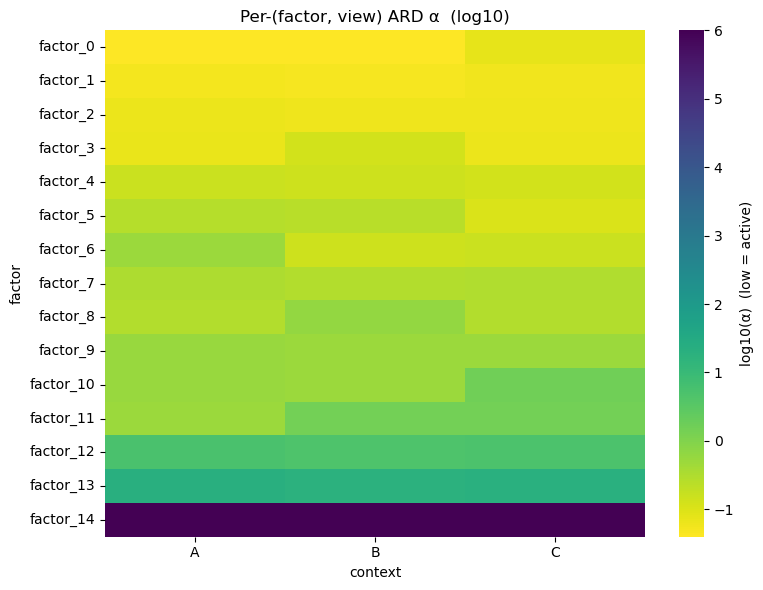

In [41]:
fig, axes = plt.subplots(1, 2 if r2_df is not None else 1,
                          figsize=(16 if r2_df is not None else 8, max(6, 0.25*N_FACTORS+1)))
if r2_df is None:
    axes = [axes]
sns.heatmap(np.log10(alpha_df), ax=axes[0], cmap='viridis_r',
            cbar_kws={'label': 'log10(α)  (low = active)'},
            xticklabels=True, yticklabels=True)
axes[0].set_title('Per-(factor, view) ARD α  (log10)')
axes[0].set_ylabel('factor'); axes[0].set_xlabel('context')

if r2_df is not None:
    sns.heatmap(r2_df, ax=axes[1], cmap='magma',
                cbar_kws={'label': 'R²'},
                xticklabels=True, yticklabels=True)
    axes[1].set_title('Variance explained R² per (factor, view)')
    axes[1].set_ylabel(''); axes[1].set_xlabel('context')

plt.tight_layout(); plt.savefig(OUT_DIR / 'factor_activity_heatmaps.png', dpi=120, bbox_inches='tight'); plt.show()


## 14. Save axes metadata

Drug order, perturbation list, gene list — useful for any downstream code that
needs to align matrices.


In [42]:
with open(OUT_DIR / 'axes.json', 'w') as f:
    json.dump({
        'contexts':       contexts,
        'genes':          sample_names,     # MOFA samples
        'perturbations':  feature_names,    # MOFA features
        'n_factors':      int(Z.shape[1]),
        'gene_median_thr': GENE_MEDIAN_THR,
        'seed':           SEED,
    }, f, indent=2)
print(f'axes.json  ({len(sample_names)} genes, {len(feature_names)} perts, {len(contexts)} views)')


axes.json  (60 perts, 5000 genes, 3 views)


## 15. Classify factors as shared / private / partial

A factor is **active in a view** if its α is below `2 × median(α)` (loadings
un-shrunken). Then:

- **Shared** — active in ≥ K−1 of K views
- **Private** — active in exactly 1 view
- **Partial** — active in 2 to K−2 views
- **Dead** — active in 0 views (ARD pruned)


In [43]:
alpha_arr = alpha_df.values                  # (n_factors, n_views)
thr = 2.0 * np.median(alpha_arr)
active = alpha_arr < thr                     # (n_factors, n_views)
n_active = active.sum(axis=1)

def label_factor(n):
    if n == 0:           return 'dead'
    if n == 1:           return 'private'
    if n >= len(contexts)-1: return 'shared'
    return f'partial ({n}/{len(contexts)})'

summary = pd.DataFrame({
    'factor':         factor_cols,
    'n_active_views': n_active,
    'label':          [label_factor(n) for n in n_active],
    'min_alpha':      alpha_arr.min(1),
    'max_alpha':      alpha_arr.max(1),
    'active_views':   [','.join(d for d, a in zip(contexts, row) if a) for row in active],
})
summary.to_csv(OUT_DIR / 'factor_summary.csv', index=False)
print(summary.to_string(index=False))
print()
print(f'Counts:  shared={(n_active >= len(contexts)-1).sum()},  '
      f'private={(n_active == 1).sum()},  '
      f'partial={((n_active>=2)&(n_active<=len(contexts)-2)).sum()},  '
      f'dead={(n_active==0).sum()}')


   factor  n_active_views   label      min_alpha      max_alpha active_views
 factor_0               3  shared       0.039729       0.072764        A,B,C
 factor_1               3  shared       0.049538       0.055883        A,B,C
 factor_2               3  shared       0.060780       0.064928        A,B,C
 factor_3               3  shared       0.065780       0.129310        A,B,C
 factor_4               3  shared       0.128406       0.154098        A,B,C
 factor_5               3  shared       0.101377       0.270524        A,B,C
 factor_6               3  shared       0.148331       0.502813        A,B,C
 factor_7               3  shared       0.291125       0.318201        A,B,C
 factor_8               2  shared       0.275907       0.631467          A,C
 factor_9               3  shared       0.505660       0.539856        A,B,C
factor_10               2  shared       0.500340       1.611125          A,B
factor_11               1 private       0.520995       1.528130            A

## 16. Top-loading genes per factor

For each factor, look at the loadings in the view where it's most active (smallest α).
Top genes are the directly readable gene program for that factor in that view.


In [44]:
def top_loadings(Z_arr, gene_names, k, n_top=15):
    """Top up/down genes for factor k from the (n_genes × n_factors) Z matrix."""
    z = Z_arr[:, k]
    up = np.argsort(z)[-n_top:][::-1]
    dn = np.argsort(z)[:n_top]
    return pd.DataFrame({
        'top_up':   [gene_names[i] for i in up],
        'up_w':     z[up].round(3),
        'top_dn':   [gene_names[i] for i in dn],
        'dn_w':     z[dn].round(3),
    })

# Inspect the first 5 non-dead factors
non_dead = [k for k in range(N_FACTORS) if n_active[k] > 0]
for k in non_dead[:5]:
    v_star = contexts[int(np.argmin(alpha_arr[k]))]
    print(f'\n=== factor_{k}  ({summary.loc[k, "label"]})  '
          f'most active in {v_star} (alpha={alpha_arr[k].min():.3f}) ===')
    print(top_loadings(Z, sample_names, k, n_top=10).to_string(index=False))



=== factor_0  (shared)  most active in B (α=0.04) ===
            top_up  up_w             top_dn   dn_w
              ERN1 0.941             UBQLN1 -0.771
              ERN2 0.920            TMEM258 -0.746
   SYN_SHARED_0885 0.888              HSPA5 -0.744
   SYN_SHARED_0852 0.778             ATP2A2 -0.744
   SYN_SHARED_0502 0.773              CXCL8 -0.744
              NOD1 0.755    SYN_SHARED_0402 -0.744
SYN_ER_STRESS_0002 0.748               UFM1 -0.743
SYN_ER_STRESS_0003 0.748 SYN_ER_STRESS_0008 -0.742
   SYN_SHARED_0297 0.747            TMEM259 -0.741
             CREB3 0.743              TMTC3 -0.740

=== factor_1  (shared)  most active in B (α=0.05) ===
            top_up  up_w          top_dn   dn_w
   SYN_SHARED_0795 0.985 SYN_SHARED_0250 -0.738
            MARCKS 0.877             UXT -0.728
   SYN_SHARED_0647 0.729           NFKB1 -0.726
   SYN_SHARED_0602 0.728          CARD14 -0.722
              CTSC 0.725           NLRP2 -0.720
             PSMA5 0.722           BUB1B 

## 17. (Optional) Visualize factor matrix Z by context

Z is `(n_perts, n_factors)`. The same pert appears once in Z (the joint
representation), but you can colour by KO target or any pert metadata.


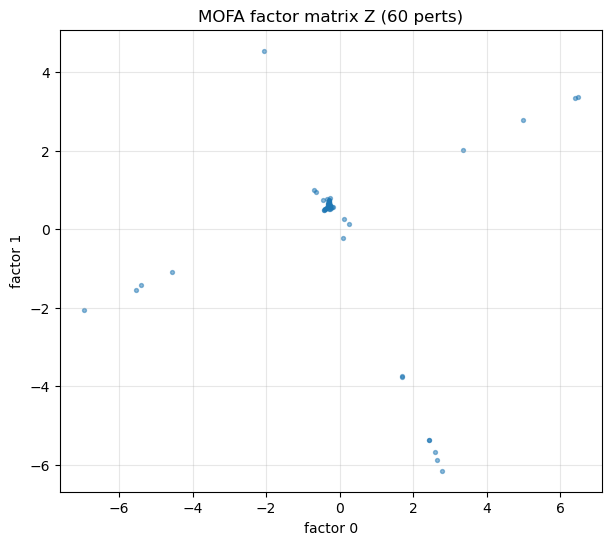

In [45]:
# Quick scatter: factor 0 vs factor 1, points = perturbations
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(Z[:, 0], Z[:, 1], s=8, alpha=0.5)
ax.set_xlabel('factor 0'); ax.set_ylabel('factor 1')
ax.set_title(f'MOFA factor matrix Z ({Z.shape[0]} perts)')
ax.grid(alpha=0.3)
plt.show()


## 18. (Next steps)

From here you can:

1. **ORA on top genes per factor** — feed top-loading gene lists into the same
   hypergeometric ORA used in notebooks 15–17 to label what each factor *is*.
2. **Compare with the deep VAE variants** — the activity matrix from
   `14_3_VAEModel_singleblock` (`factor_view_activity.parquet`) is the deep
   analogue of `factor_view_alpha.parquet`. Both should agree on which factors
   are shared vs private; disagreements highlight non-linear structure that the
   linear MOFA misses.
3. **Pert metadata overlay** — colour Z by KO target / pathway membership to see
   whether known biology clusters in factor space.
4. **Drug-context interpretation** — for partial / private factors, the active
   views indicate which context contexts share that program — these are candidate
   context-class programs.
